In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

In [5]:
df = pd.read_csv('letter-recognition.csv')

print("Dataset Shape  :", df.shape)
print("Column Names   :", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nClass distribution (how many of each letter):")
print(df.iloc[:, 0].value_counts().sort_index())

Dataset Shape  : (20000, 17)
Column Names   : ['letter', 'xbox ', 'ybox ', 'width ', 'height', 'onpix ', 'xbar ', 'ybar ', 'x2bar', 'y2bar ', 'xybar ', 'x2ybar', 'xy2bar', 'xedge ', 'xedgey', 'yedge ', 'yedgex']

First 5 rows:
  letter  xbox   ybox   width   height  onpix   xbar   ybar   x2bar  y2bar   \
0      T      2      8       3       5       1      8     13      0       6   
1      I      5     12       3       7       2     10      5      5       4   
2      D      4     11       6       8       6     10      6      2       6   
3      N      7     11       6       6       3      5      9      4       6   
4      G      2      1       3       1       1      8      6      6       6   

   xybar   x2ybar  xy2bar  xedge   xedgey  yedge   yedgex  
0       6      10       8       0       8       0       8  
1      13       3       9       2       8       4      10  
2      10       3       7       3       7       3       9  
3       4       4      10       6      10       2       8 

In [7]:
# First column = letter (target), rest = 16 features (input)
X = df.iloc[:, 1:].values   # All rows, columns 1 to end (16 features)
y = df.iloc[:, 0].values    # All rows, column 0 only (letters A-Z)

print("\nFeatures shape (X):", X.shape)   # (20000, 16)
print("Labels shape   (y):", y.shape)    # (20000,)
print("Sample labels  :", y[:10])        # ['T', 'I', 'D', ...]



Features shape (X): (20000, 16)
Labels shape   (y): (20000,)
Sample labels  : ['T' 'I' 'D' 'N' 'G' 'S' 'B' 'A' 'J' 'M']


In [9]:
# Step 4a: LabelEncoder converts A-Z → 0-25
label_encoder = LabelEncoder()
y_encoded     = label_encoder.fit_transform(y)

print("\nAfter LabelEncoder:")
print("Sample:", y[:5], "→", y_encoded[:5])

# Step 4b: to_categorical converts 0-25 → one-hot vectors
num_classes = len(label_encoder.classes_)   # = 26
y_onehot    = to_categorical(y_encoded, num_classes=num_classes)

print("\nAfter to_categorical (one-hot):")
print("Shape:", y_onehot.shape)       # (20000, 26)
print("Sample letter A:", y_onehot[np.where(y=='A')[0][0]])


After LabelEncoder:
Sample: ['T' 'I' 'D' 'N' 'G'] → [19  8  3 13  6]

After to_categorical (one-hot):
Shape: (20000, 26)
Sample letter A: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]


In [11]:
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X)

print("\nBefore scaling - Feature range:", X.min(), "to", X.max())
print("After scaling  - Feature range:", round(X_scaled.min(),2),
      "to", round(X_scaled.max(),2))


Before scaling - Feature range: 0 to 15
After scaling  - Feature range: -5.39 to 5.74


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_onehot,
    test_size=0.2,
    random_state=42
)

print("\nTraining set shape:", X_train.shape, y_train.shape)
print("Testing set shape :", X_test.shape,  y_test.shape)



Training set shape: (16000, 16) (16000, 26)
Testing set shape : (4000, 16) (4000, 26)


In [15]:
model = Sequential()

# First Hidden Layer: 256 neurons, ReLU, accepts 16 features
model.add(Dense(256, input_dim=16, activation='relu'))
model.add(Dropout(0.3))

# Second Hidden Layer: 128 neurons, ReLU
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

# Third Hidden Layer: 64 neurons, ReLU
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))

# Output Layer: 26 neurons (one per letter), Softmax
model.add(Dense(26, activation='softmax'))

model.summary()


C:\Users\Lenovo\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 26)                  │           1,690 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 47,194 (184.35 KB)

 Trainable params: 47,194 (184.35 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [19]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.2395 - loss: 2.6438 - val_accuracy: 0.6775 - val_loss: 1.1177
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5906 - loss: 1.2729 - val_accuracy: 0.7681 - val_loss: 0.7997
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6785 - loss: 1.0235 - val_accuracy: 0.7947 - val_loss: 0.6864
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7240 - loss: 0.8884 - val_accuracy: 0.8341 - val_loss: 0.5854
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7491 - loss: 0.7834 - val_accuracy: 0.8416 - val_loss: 0.5235
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7601 - loss: 0.7268 - val_accuracy: 0.8541 - val_loss: 0.4794
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7898 - loss: 0.6673 - val_accuracy: 0.8753 - val_loss: 0.4265
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8078 - loss: 0.6067 - val_accuracy: 

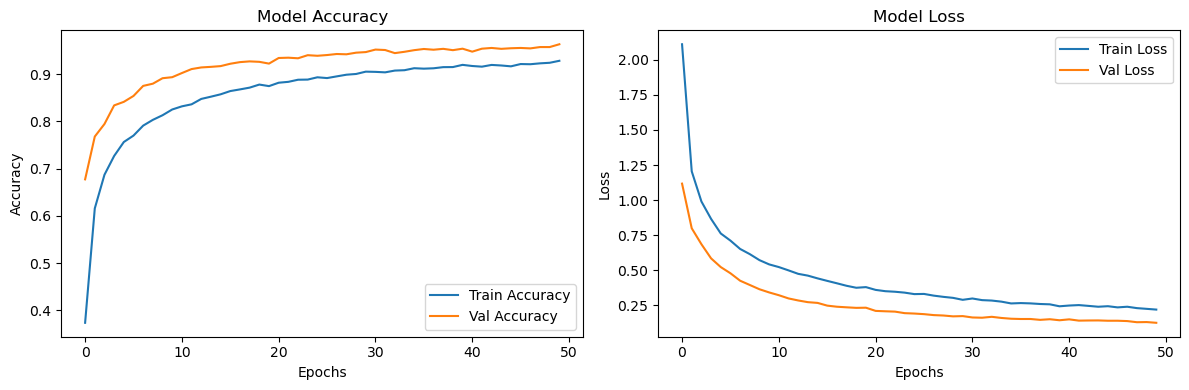

In [21]:
plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'\nTest Accuracy : {test_acc:.4f}')
print(f'Test Loss     : {test_loss:.4f}')

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9609 - loss: 0.1236

Test Accuracy : 0.9615
Test Loss     : 0.1178


In [25]:
# ═══════════════════════════════════════
predictions       = model.predict(X_test)
predicted_indices = np.argmax(predictions, axis=1)
actual_indices    = np.argmax(y_test,       axis=1)

# Convert indices back to actual letters
predicted_letters = label_encoder.inverse_transform(predicted_indices)
actual_letters    = label_encoder.inverse_transform(actual_indices)

print("\nSample Predictions (first 15):")
print("Predicted:", predicted_letters[:15])
print("Actual   :", actual_letters[:15])

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Sample Predictions (first 15):
Predicted: ['Z' 'L' 'A' 'E' 'Q' 'E' 'O' 'Q' 'G' 'O' 'B' 'P' 'V' 'Q' 'M']
Actual   : ['T' 'L' 'A' 'E' 'Q' 'E' 'O' 'Q' 'G' 'O' 'B' 'P' 'V' 'Q' 'M']


In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("\nClassification Report:")
print(classification_report(actual_letters, predicted_letters))


Classification Report:
              precision    recall  f1-score   support

           A       0.99      0.99      0.99       149
           B       0.91      0.96      0.94       153
           C       0.98      0.94      0.96       137
           D       0.94      0.97      0.95       156
           E       0.94      0.96      0.95       141
           F       0.94      0.96      0.95       140
           G       0.92      0.97      0.95       160
           H       0.93      0.88      0.90       144
           I       0.97      0.95      0.96       146
           J       0.95      0.97      0.96       149
           K       0.95      0.89      0.92       130
           L       0.97      0.97      0.97       155
           M       0.99      0.99      0.99       168
           N       0.99      0.95      0.97       151
           O       0.95      0.95      0.95       145
           P       0.99      0.93      0.96       173
           Q       0.97      0.99      0.98       166
   